# 🎙️ OmniASR-CTC-300M — Tunisian Arabic ASR Benchmark

**Model:** facebook/omniASR-CTC-300M  
**Config key:** omniasr_ctc_300M

 > OmniASR uses the omnilingual-asr package (fairseq2-based), NOT HF Transformers.  
 > Inference goes through ASRInferencePipeline with Arabic language tag ara_Arab.  
 > Audio is passed as [{'waveform': array, 'sample_rate': sr}] dicts.  
 > Constraint: segments must be ≤ 40 s; longer audio must be pre-chunked.

## 1 · Install & Imports

In [1]:
# SETUP INSTRUCTIONS FOR LOCAL SERVER
# =====================================
# omnilingual-asr has broken dependencies on PyPI (fairseq2n missing).
# Install manually before running this notebook:
#
# conda create -n omni python=3.10 -y
# conda activate omni
# pip install --no-deps omnilingual-asr
# pip install datasets evaluate jiwer pyyaml torch numpy
# 
# Then select kernel: "Python 3.10 (omni)" and run this notebook.
# ===================================================================

# If packages are already installed, comment out this cell and proceed.
# !pip install -q omnilingual-asr datasets evaluate jiwer pyyaml
# !apt-get install -y -q libsndfile1  # For audio processing on Linux

In [2]:
# Local path to benchmarking package
import sys
from pathlib import Path

BENCHMARK_ROOT = Path('/home/ala/dataset')
assert BENCHMARK_ROOT.exists(), f'Missing path: {BENCHMARK_ROOT}'

if str(BENCHMARK_ROOT) not in sys.path:
    sys.path.insert(0, str(BENCHMARK_ROOT))

print('Using benchmark root:', BENCHMARK_ROOT)

Using benchmark root: /home/ala/dataset


In [3]:
from benchmark_utils import (
    load_config, get_device, print_gpu_info, setup_output_dir,
    load_benchmark, split_benchmark,
    compute_metrics, per_sample_wer,
    run_pipeline_inference, build_results_df,
    run_labelled_splits, run_unlabelled_splits,
    display_preview, display_worst, display_bulk_predictions,
    audio_inspector, display_summary, plot_wer_cer,
)
import numpy as np
import torch
import time
from pathlib import Path
from tqdm.auto import tqdm
from datasets import Audio as HFAudio

cfg = load_config(str(BENCHMARK_ROOT / 'config.yaml'))

# Override Colab-only paths for local execution
cfg['paths']['dataset'] = str(BENCHMARK_ROOT)
cfg['paths']['output_root'] = str(Path('/home/ala/TunisianDialogSystem/outputs/asr_benchmark_results'))

TARGET_SR    = cfg['evaluation']['target_sr']
TOP_N_WORST  = cfg['evaluation']['top_n_worst']
PREVIEW_ROWS = cfg['evaluation']['preview_rows']
RESUME = False

print('Dataset path:', cfg['paths']['dataset'])
print('Output root :', cfg['paths']['output_root'])

Dataset path: /home/ala/dataset
Output root : /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results


## 2 · GPU Check

In [4]:
device = get_device()
print_gpu_info()

Device : cuda
GPU    : NVIDIA GB10
VRAM   : 128.5 GB total  |  128.5 GB free


## 3 · Load Model & Pipeline

### 3.1 Load `ASRInferencePipeline` (`omniASR_CTC_300M`)
`ASRInferencePipeline` downloads and caches the model weights on first call.
Pass `model_card` exactly as listed in the omnilingual-asr registry.

| Parameter | Value | Note |
|-----------|-------|--------|
| `model_card` | `omniASR_CTC_300M` | Registry name |  
| `language` | `ara_Arab` | BCP-47 + script |  
| `batch_size` | from config | Tune to GPU VRAM |



In [5]:
!pip install torchaudio retrying

In [6]:
import sys
sys.path.insert(0, '/home/ala/fairseq2/src')
sys.path.insert(0, '/home/ala/fairseq2/native/python/src')

from omnilingual_asr.models.inference.pipeline import ASRInferencePipeline

In [ ]:
from omnilingual_asr.models.inference.pipeline import ASRInferencePipeline

mcfg        = cfg['models']['omniasr_ctc_300M']
OUTPUT_DIR  = setup_output_dir(cfg, 'omniasr_ctc_300M')
FILE_SUFFIX = 'omniasr_ctc_300M_results'
BATCH_SIZE  = mcfg['batch_size']
LANG        = mcfg['language']

print("Loading omniASR_CTC_300M ...")
omni_pipe = ASRInferencePipeline(model_card=mcfg['model_card'])
print("✓ omniASR_CTC_300M loaded")

KeyError: 'omniasr_ctc_300M'

## 4 · Mount Drive & Load Benchmark

In [ ]:
from datasets import DatasetDict, load_from_disk

# Build a DatasetDict from available on-disk split folders only
split_dirs = sorted([p for p in BENCHMARK_ROOT.iterdir() if p.is_dir()])
benchmark = DatasetDict()

for p in split_dirs:
    try:
        benchmark[p.name] = load_from_disk(str(p))
    except Exception:
        pass

print(f"Loaded splits: {list(benchmark.keys())}")
LABELLED_SPLITS, UNLABELLED_SPLITS = split_benchmark(benchmark)

Loaded splits: ['labeled_algerian', 'labeled_linagora_cs_arabize', 'labeled_linagora_raw', 'unlabeled_youtube']
Labelled splits   : ['labeled_algerian', 'labeled_linagora_cs_arabize', 'labeled_linagora_raw']
Unlabelled splits : ['unlabeled_youtube']


## 5 · Inference

In [ ]:
!pip install torchcodec

In [ ]:
import sys
print(sys.executable)
import torchcodec
print('torchcodec', torchcodec.__version__)
import torch
print('torch', torch.__version__, 'cuda_available=', torch.cuda.is_available())

/home/ala/miniconda3/envs/omni-py310/bin/python
torchcodec 0.11.1+cu130
torch 2.11.0+cu130 cuda_available= True


In [ ]:
RESUME = False

# OmniASR hard limit: <= 40 seconds per segment
MAX_ASR_SEC = 40.0
CHUNK_SEC = 39.5  # safety margin
CHUNK_SAMPLES = int(TARGET_SR * CHUNK_SEC)

def _split_audio_for_omniasr(waveform: np.ndarray, sample_rate: int = TARGET_SR):
    """Return a list of ASR input dicts, each <= 40s."""
    if waveform is None or len(waveform) == 0:
        return [{'waveform': np.zeros(1, dtype=np.float32), 'sample_rate': sample_rate}]

    max_allowed = int(MAX_ASR_SEC * sample_rate)
    if len(waveform) <= max_allowed:
        return [{'waveform': waveform.astype(np.float32), 'sample_rate': sample_rate}]

    chunks = []
    for start in range(0, len(waveform), CHUNK_SAMPLES):
        seg = waveform[start:start + CHUNK_SAMPLES]
        if len(seg) == 0:
            continue
        chunks.append({'waveform': seg.astype(np.float32), 'sample_rate': sample_rate})
    return chunks


def infer_fn(ds):
    """
    Wraps ASRInferencePipeline.transcribe().
    Input format: [{'waveform': np.ndarray, 'sample_rate': int}]
    Language tag: 'ara_Arab'.
    Handles OmniASR 40s limit by auto-chunking long audio.
    """
    ds = ds.cast_column('audio', HFAudio(sampling_rate=TARGET_SR))
    predictions, latencies = [], []
    start = time.time()

    for i in tqdm(range(0, len(ds), BATCH_SIZE), desc='Inferring', unit='batch'):
        batch = ds.select(range(i, min(i + BATCH_SIZE, len(ds))))

        # Build per-sample chunk lists
        chunked_per_sample = []
        for x in batch:
            wav = np.array(x['audio']['array'], dtype=np.float32)
            chunked_per_sample.append(_split_audio_for_omniasr(wav, TARGET_SR))

        # Flatten for one transcribe call
        flat_audio_data = [chunk for sample_chunks in chunked_per_sample for chunk in sample_chunks]

        t0 = time.time()
        flat_texts = omni_pipe.transcribe(
            flat_audio_data,
            lang=[LANG] * len(flat_audio_data),
            batch_size=BATCH_SIZE,
        )
        elapsed = time.time() - t0

        # Recompose chunk texts back to one text per original sample
        pos = 0
        for sample_chunks in chunked_per_sample:
            n = len(sample_chunks)
            sample_text = ' '.join(t.strip() for t in flat_texts[pos:pos + n] if isinstance(t, str)).strip()
            predictions.append(sample_text)
            # Keep one latency value per original sample
            latencies.append(elapsed / max(1, len(chunked_per_sample)))
            pos += n

    return predictions, latencies, time.time() - start


all_result_dfs, summary_rows = run_labelled_splits(
    benchmark,
    LABELLED_SPLITS,
    infer_fn,
    OUTPUT_DIR,
    FILE_SUFFIX,
    PREVIEW_ROWS,
    TOP_N_WORST,
    resume=RESUME,
)


  Running: labeled_algerian  (500 samples)



  Running: labeled_algerian  (500 samples)


Inferring:   0%|          | 0/125 [00:00<?, ?batch/s]


  Running: labeled_algerian  (500 samples)


Inferring:   0%|          | 0/125 [00:00<?, ?batch/s]

...

  WER              : 0.9843
  CER              : 0.9224
  RTF              : 0.0105
  Total audio      : 3.987 h
  Inference time   : 151.2 s
  Mean latency/smp : 0.2906 s
  Median latency   : 0.2806 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_3b_results/labeled_algerian_omniasr_ctc_3b_results.csv

  Running: labeled_linagora_cs_arabize  (5482 samples)


Inferring:   0%|          | 0/1371 [00:00<?, ?batch/s]

  WER              : 0.6842
  CER              : 0.3249
  RTF              : 0.0236
  Total audio      : 6.015 h
  Inference time   : 510.3 s
  Mean latency/smp : 0.0915 s
  Median latency   : 0.0757 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_3b_results/labeled_linagora_cs_arabize_omniasr_ctc_3b_results.csv

  Running: labeled_linagora_raw  (5482 samples)


Inferring:   0%|          | 0/1371 [00:00<?, ?batch/s]

  WER              : 0.6795
  CER              : 0.3470
  RTF              : 0.0235
  Total audio      : 6.015 h
  Inference time   : 509.7 s
  Mean latency/smp : 0.0914 s
  Median latency   : 0.0769 s
  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_3b_results/labeled_linagora_raw_omniasr_ctc_3b_results.csv

✅ All labelled splits done.


## 6 · Per-sample preview

In [ ]:
display_preview(all_result_dfs, PREVIEW_ROWS)


── labeled_algerian ──


,reference,prediction,sample_wer,duration_s
0,في الدار البيضاء ومقاولات كبيرة بسبب الضبابية بسبب هاد الفراغ لي كاين ليوما على مستوى الاقتصاد السياسي واللي دخلنا في الركود التضخمي يعني التضخم دي اقتصادي هابط التراجع ديال النمو والشركات د القطاع الخصوصي الكبيرة كتكمن تقنن النفقات ديالها نقتاسم التوظيف وبالتالي يعني واحد السياسة احترازية,فضل لبيضاع ومقاوكبيرسبب الضبابةتنموالشرت القطا الخصوصي الكبيرةن انفقاتقضيف سيسحية,0.978,30.000000
1,في ولا ولا هذا ولا هادشي لي كنت كنقرا وليت راسي كنتوجه الذكاء المالي التطور الشخصي انا دابا انا دابا بديت في التطور الشخصي قريت عليه وبديت كنت كنقرا وبغيت ندير التطور الشخصي ماشي باش نحل مشاكل الناس اللي مجوجين ديالك اه بغيت بغيت التطور الشخصي نخدمو فالتطور,التطور الشخ ر لتطورالش شالارش,0.979,28.650000
2,تكون التجربة ما عندهاش طعم وداك الانتقال من انك دكتور في الجامعة المغربية لأنك مدرب في الجامعة الدولية كي كان هاد الإنتقال وانا انا بديت يعني بديت العمل ديالي في جامعة خارج المغرب سواء في المملكة العربية السعودية وفي الإمارات او في الولايات المتحدة الأمريكية اه ولا كنت في طور يعني ده,جر ع انال ن و المعة المربية ن مدرب فامع الولية العمل ف جامعة خارج المغرب ملك العربية السعدية الإمارات الولايت المتحدة الأمريكية,0.827,29.250000
3,كاين واحد التعقيد يراد به واحد المجموعة د الأشياء فمن تم يعني درت الدكتوراه في الفين بديت في الفين وتلطاش سنة الفين وتمنطاش ومن تم يعني كذلك يعني طورت القضية ديال الاستشارات المالية التدقيق الشرعي ديال الأيوفي هيئة المراجعة والمحاسبة المعاملات المالية الإسلامية,ل ل شي ت استشارات المالية ي الشرا اةس اليسلا,0.977,26.600000
4,ديال ديال كل واحد يديها فراسو حسن ليه من المشاكل نديها فراسي ناس جاب نشوف لاخر نشوف راسي انا المصلحة ديالي لا ولا هاد كيقولك اودي المسؤولية ديالهم توقع على الدولة هوما اللي هادي وهادي لا انا كنقول الذي يحرك هاد الرقي الاجتماعي هو منظومة القيم التي نعيشها,كلر اجتمظ ا,1.000,27.350000
5,غير معرفتش واش دابا نضحك ولا نكون معقول لي بغيت كنعرف يعني البرامج ديالك كيكون فيهم بزاف وانا معرفتش نكون المهم هو تعاودلي حكايتي عجبني العنوان شكرا كنهنئك واخا انا عرفت بان شهرزاد ديالي كانت كتحكي لشهر ايار لا بالعكس ماكاين تا مشكل توكلي على الله يالاه ها حنا غانمشيو,,1.000,28.150000
6,البناء اه بطبيعة الحال را الاعتدال مطلوب يعني ميمكنلناش نتصورو يعني اي بناء اولا توجه نحو التنمية بدون اعتدال لان لا الغلو ويضر والتراخي عاوتاني ايضا الغلو الدفاع مضر والتراخي ايضا مضر وبالتالي ان الاعتدال اساسي حنا المغرب منذ ثلاثة وتسعين والتوجه ديال المغرب في علاقة يعني القطع,ل طلب بنا لن ل ر دل لر م,1.000,27.650000
7,ديالكم حاولوا ما امكن تاخدوا مية فالمية ها حنا دابا وجدنا الأرض ديالنا اللي غادي ترتاح حتى الوقيتة ديال الربيع اللي خصنا نبداو نغرسوه الحاجة لي مهمة بزاف خصنا لي خصنا ناخدوهم هما الحمد لله دابا ولاو عندنا هاد فالمغرب للأسف مازال ما عندناش لي مية فالمية مغربيين ولكن اه نقدرو نلقاو لي,,1.000,27.050000
8,كتخلص رسوم ديال التسجيل والتحفيض الى غير ذلك كتعلم ادارة الضرائب لأن كاين رسوم تسجيل كتأدى تاهو راه بمثابة اعلام واشعار الى غير ذلك ذلك اه اه كدلك خصنا نعلمو السلطة متلا ربما سكن ثانوي ولى سكن رئيسي وخا لأن الضريبة تختلي انا غادي نمشي نعلم فين غادي قلتي الجماعة نعم كاينة الجماعات وكاينة ادارة,,1.000,30.000000
9,مكاين تا واحد القيمة ديالو شحال غادي طيح تقمارت ولا ماشي تاقمرت معمرو يولي زيرو هدا النفط معمرو يولي زيرو ايجي شي واحد يقولك هادوك ديال ابريل الفين وعشرين كانوا هادوك هداك ماشي البرميل ديال النفط يعني اداة مقامرة او كيهيمنو عل الميدان المالي اليوم مع الأسف,ة مقار لميدان المال س,1.000,27.400000



── labeled_linagora_cs_arabize ──


,reference,prediction,sample_wer,duration_s
0,و الله لا وراس لا و الله مقتنع و الله اسمعني س ديجا,زلت مقتنع لي اتيتحب تبطل جسبي يقعد معايا,1.000,7.776000
1,استفتاء,estefti,1.000,1.264000
2,يكري كرهبة,يسركسب,1.000,0.880000
3,عبد الله مشى سال طفلة,عضلهف شي سل طفلة,0.800,1.528000
4,هاذي غلطتي مش غلطتك,هذي غаلتي مش غالt,0.750,2.216000
5,بودكاستينق يت ماكس ماي داي على خاطر فمة عباد تسمع فيك و يهمها لي تحكي فيه و كل و ذاي كير اباوت يو و يخمموا معناها,على خاطر فمعبي تسمع فيك ويهمها اللي تحكي فيه وكليخمو ه,0.769,9.560000
6,يطفيو الضو خلي قطر ولا الامارات تهز حتى كاس الحومة توا تشوف دنيا كيفاش تتقلب,إطفيو الضوء خلي قطر وإلا الإمارات تز حتى كأس الحومة توا تشوف الدنيا كيفاش تتقلب,0.467,6.424000
7,عبد الله سال لمرا في القيشي,عبدالله sيلمفšي,1.000,1.848000
8,كله كوم و ها قصر العداله الجديد الي تبنا كوم آخر الي هو خوك زكربرك ربي يفضله بنلنا ها القصر هذايا البلو,كل كوم وها قصر العدالة الجديد اللي تبناء كوم آخر اللي هو خوك زوكربيرغ ربي فضلو بنانها القصر هذيا البلو,0.545,8.712000
9,الي هو فيسبوك,اللي هو فيسبوك,0.333,1.056000



── labeled_linagora_raw ──


,reference,prediction,sample_wer,duration_s
0,و الله لا وراس لا و الله مقتنع و الله اسمعني c'إي déjà,زلت مقتنع لي اتيتحب تبطل جسبي يقعد معايا,1.000,7.776000
1,استفتاء,estefti,1.000,1.264000
2,يكري كرهبة,يسركسب,1.000,0.880000
3,عبد الله مشى سأل طفلة,عضلهف شي سل طفلة,0.800,1.528000
4,هذي غلطتي موش غلطتك,هذي غаلتي مش غالt,0.750,2.216000
5,podcasting it makes my day على خاطر فمة عباد تسمع فيك و يهمها لي تحكي فيه و كل و they care about you و يخمموا معناها,على خاطر فمعبي تسمع فيك ويهمها اللي تحكي فيه وكليخمو ه,0.769,9.560000
6,يطفيو الضو خلي قطر ولا الامارات تهز حتى كأس الحومة توا تشوف دنيا كيفاش تتقلب,إطفيو الضوء خلي قطر وإلا الإمارات تز حتى كأس الحومة توا تشوف الدنيا كيفاش تتقلب,0.400,6.424000
7,عبد الله سأل لمرا في القيشي,عبدالله sيلمفšي,1.000,1.848000
8,كله كوم و ها قصر العداله الجديد إلي تبنا كوم آخر إلي هو خوك زكربرك ربي يفضله بنلنا ها القصر هذايا البلو,كل كوم وها قصر العدالة الجديد اللي تبناء كوم آخر اللي هو خوك زوكربيرغ ربي فضلو بنانها القصر هذيا البلو,0.545,8.712000
9,إلي هو فيسبوك,اللي هو فيسبوك,0.333,1.056000


## 7 · Worst predictions

In [ ]:
display_worst(all_result_dfs, TOP_N_WORST)


── labeled_algerian — top 15 worst predictions ──



── labeled_algerian — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
278,هوما الناس لي راسهم صغير وكيستافدو ومتيقولش ليك واحد الحاجة انا عارف لاحظ هادي هادي لحظة تلاقا مع شي واحد واصل فشي ياك تلاقا مع ماعمر غتجلس نتا وياه وغيقولك لا ما عمرك غتسمع منو وانا عارف ولا هذا الى ريحتي معاه اش كيدير تيريح تيخليك تهضر يالاه ودابا شوف هاد,باش نعترف لك فيه بوحد السر اللي كنت خبيت علك محال هذا منهارتزاديتي وهات الشريطة ولدي راما غادي تسمعو حتى نكون أنا يا ما بين الحياة أو الموت ولا غادي تلقاه غير بالصدفة من بعد ما غادي نموت قالت لها ولدي نتعارف بلي بطبية الحال كنبغيك بزاف ونت أعز ولادي وعمري قصرت منجهتك بشي حاجة ولا بخلت علك بشي حاجة عمري مديت دي عليك ولا خليتك تحتاجلشي حاجة خاصكتعرفها ولدي بلي انت,1.373,29.600000
83,يعطيك الصحة مرة أخرى وثاني للناس هنا معظم متابعينا تقدر تقول عندهم خلفية تقنية لكن كاين ما شاء الله الناس في المجالات متخصصة وحداخرى نحاولو علابيها رانا نحاولو النوعو ثاني المحتوى في هذا الموسم ولي يهتم ثاني بلاك في هذا الموضوع ولكن من ناحية التقنية كاين الحلقة سجلناها مع الأخ,علي الاقل اعطيهم امتيازات اعطيهم حوايج الل يقدرو يجوك علي بهان المدن داخله باش نقدرو نديرو قطب مليح كالجانوبيعودو يجو يقراو عدنا ت ع الجلفه وركله ومشونزيد لك كارثه واحد اخري هيتصرا سيك مبعد هاذي في اليسما في التدرج يسمه باش تلحق ماستر مبعد المشكله فلقالي روحو دكتورا سما الاشكال نهاره لقناس راحو الدكتورا كيدير انت جامعات بارتو تما شغل الاشكال يدخل فيها المحسوبيه و الجهويه,1.300,28.432750
4,ديال ديال كل واحد يديها فراسو حسن ليه من المشاكل نديها فراسي ناس جاب نشوف لاخر نشوف راسي انا المصلحة ديالي لا ولا هاد كيقولك اودي المسؤولية ديالهم توقع على الدولة هوما اللي هادي وهادي لا انا كنقول الذي يحرك هاد الرقي الاجتماعي هو منظومة القيم التي نعيشها,كلر اجتمظ ا,1.000,27.350000
5,غير معرفتش واش دابا نضحك ولا نكون معقول لي بغيت كنعرف يعني البرامج ديالك كيكون فيهم بزاف وانا معرفتش نكون المهم هو تعاودلي حكايتي عجبني العنوان شكرا كنهنئك واخا انا عرفت بان شهرزاد ديالي كانت كتحكي لشهر ايار لا بالعكس ماكاين تا مشكل توكلي على الله يالاه ها حنا غانمشيو,,1.000,28.150000
6,البناء اه بطبيعة الحال را الاعتدال مطلوب يعني ميمكنلناش نتصورو يعني اي بناء اولا توجه نحو التنمية بدون اعتدال لان لا الغلو ويضر والتراخي عاوتاني ايضا الغلو الدفاع مضر والتراخي ايضا مضر وبالتالي ان الاعتدال اساسي حنا المغرب منذ ثلاثة وتسعين والتوجه ديال المغرب في علاقة يعني القطع,ل طلب بنا لن ل ر دل لر م,1.000,27.650000
7,ديالكم حاولوا ما امكن تاخدوا مية فالمية ها حنا دابا وجدنا الأرض ديالنا اللي غادي ترتاح حتى الوقيتة ديال الربيع اللي خصنا نبداو نغرسوه الحاجة لي مهمة بزاف خصنا لي خصنا ناخدوهم هما الحمد لله دابا ولاو عندنا هاد فالمغرب للأسف مازال ما عندناش لي مية فالمية مغربيين ولكن اه نقدرو نلقاو لي,,1.000,27.050000
8,كتخلص رسوم ديال التسجيل والتحفيض الى غير ذلك كتعلم ادارة الضرائب لأن كاين رسوم تسجيل كتأدى تاهو راه بمثابة اعلام واشعار الى غير ذلك ذلك اه اه كدلك خصنا نعلمو السلطة متلا ربما سكن ثانوي ولى سكن رئيسي وخا لأن الضريبة تختلي انا غادي نمشي نعلم فين غادي قلتي الجماعة نعم كاينة الجماعات وكاينة ادارة,,1.000,30.000000
9,مكاين تا واحد القيمة ديالو شحال غادي طيح تقمارت ولا ماشي تاقمرت معمرو يولي زيرو هدا النفط معمرو يولي زيرو ايجي شي واحد يقولك هادوك ديال ابريل الفين وعشرين كانوا هادوك هداك ماشي البرميل ديال النفط يعني اداة مقامرة او كيهيمنو عل الميدان المالي اليوم مع الأسف,ة مقار لميدان المال س,1.000,27.400000
10,ولا غير با يشري رقيعة فيها غير الما يما نعرفو بلا ما يكون شي ايلا كان راه غي بالما غادي يتحيد ولا ناخدو القهوة نخويوها عليه غي غادي تمسح ديك الساعة مغادي يبقى فيه حتى شي حاجة دابا ماشي غير هدا من غير لي كيكونو لا حتى هما فيهم دابا رجع فكلشي حيت كنلقاو كيجيو مخيطين,,1.000,28.050000
11,اهاه بالعكس بالعكس نسخة ثقيل وفبزاف د الأحيان الشخصية القوية كتخلع كتخلع الرجال كتخلع وحتى هداكشي دائما كاين اهم داكشي لي كتعكسيه الواحد لي كيكون باغي يكون هو مقادرش فمكيبغيكش حيت نتي كتمتلي واحد الحاجة اللي هو باغيها اللي ما كرهش يكون هو فبلاصتو كيكون هو عندو ديك الشخصية ويقدر هو ياخد ديك القرار,الأ اشخص ق ا ش الرا,1.000,26.400000



── labeled_linagora_cs_arabize — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
3040,نرمالمن سنسي يقراو امم,يقرواله تسأل فيه تول عل على عما الحضاير متعرضين للمدرسة نعيك نعطيك معتي بودرياس في قسرين للان مسكر بالحجر,4.750,10.672000
4413,مرحبا,بلي وقت شو متوزته,4.000,1.680000
4942,الصومال,as s u mal,4.000,1.253900
3178,باهي ايه ترى بيان,ك وعنات بنا صحاب مون نا شدي رح نهارتشر نهار,2.500,4.280000
4643,يلزمنا نوفاوها بعبر,ne zena na ô fe wa ba,2.333,1.097000
125,الريح,لو ليa,2.000,0.528000
276,يقعد,ja qat,2.000,0.944000
428,بالسلامة,w słema,2.000,0.712000
565,عالسلامة,aa slema,2.000,0.760000
635,مشحاح,مش حاح,2.000,0.920000



── labeled_linagora_raw — top 15 worst predictions ──


,reference,prediction,sample_wer,duration_s
3040,نرمالمن سنسي يقراو إمم,يقرواله تسأل فيه تول عل على عما الحضاير متعرضين للمدرسة نعيك نعطيك معتي بودرياس في قسرين للان مسكر بالحجر,4.750,10.672000
4413,مرحبا,بلي وقت شو متوزته,4.000,1.680000
4942,الصومال,as s u mal,4.000,1.253900
3178,باهي أيه ترى بيان,ك وعنات بنا صحاب مون نا شدي رح نهارتشر نهار,2.500,4.280000
4643,يلزمنا نوفاوها بعبر,ne zena na ô fe wa ba,2.333,1.097000
125,الريح,لو ليa,2.000,0.528000
276,يقعد,ja qat,2.000,0.944000
428,بالسلامة,w słema,2.000,0.712000
565,عالسلامة,aa slema,2.000,0.760000
635,مشحاح,مش حاح,2.000,0.920000


## 8 · Unlabelled inspection

In [ ]:
unlabelled_result_dfs = run_unlabelled_splits(
    benchmark,
    UNLABELLED_SPLITS,
    infer_fn,
    OUTPUT_DIR,
    FILE_SUFFIX,
    resume=RESUME,
)


  Running (unlabelled): unlabeled_youtube  (398 samples)



  Running (unlabelled): unlabeled_youtube  (398 samples)


Inferring:   0%|          | 0/100 [00:00<?, ?batch/s]


  Running (unlabelled): unlabeled_youtube  (398 samples)


Inferring:   0%|          | 0/100 [00:00<?, ?batch/s]

  ✓ CSV saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_3b_results/unlabeled_youtube_omniasr_ctc_3b_results.csv

✅ All unlabelled splits done.


In [ ]:
display_bulk_predictions(unlabelled_result_dfs)


── unlabeled_youtube — all 398 predictions ──



── unlabeled_youtube — all 398 predictions ──


,prediction,duration_s,audio_id,source_url,seg_start,seg_end
0,إدارة الصيدلة والأدوية بوزارة الصحة تقرر سحب أربعة مكملات غذائية من السوق لعدم تطابقها مع المواصفات خبر قد يعتبر في ظاهره عاديا لكنه يخفي مشاكل كبرى تتعلق,14.976000,MDU2ROgeKns_0,https://www.youtube.com/watch?v=MDU2ROgeKns,0.000000,15.000000
1,صحة التونسي فهذه المواد نجدها معروضة في مسالك أخرى غير الصيداليات حيث أنها تباع ويروج لها عبر الإنترنت ومواقع التواصل الاجتماعي,15.000000,MDU2ROgeKns_1,https://www.youtube.com/watch?v=MDU2ROgeKns,15.000000,30.000000
2,اغذائية تبقى المواقع الواب اللي هما يبيعو في الأشياء هذي الحقيقة أنا مندورش بهمكنت نجري الحق ويظهرلي حاجة ب الوزارةكم قم,15.000000,MDU2ROgeKns_2,https://www.youtube.com/watch?v=MDU2ROgeKns,30.000000,45.000000
3,ن معرضالاشكال تاع المكملات الغذائية اليمصنوع في تونس اللي نجمو نلقا في الصيدريات ولا نجم نقا في أي موقع تجاري اخر ولا حتى في مواقع التواصل الاجتماعي ولا عل الانترنت مااشكال كبير في المكماتالذ,15.000000,MDU2ROgeKns_3,https://www.youtube.com/watch?v=MDU2ROgeKns,45.000000,60.000000
4,محلية اللي جود تاعهم في بعض الحالات ميكونو جيدي المصنعين محلين ما يخضعول حتى قانون ونلاحظو اللي برشا موجهين للأطفال وهذاي ختر صافي على الصاعة اصغار اليومعندا هوملص,15.000000,MDU2ROgeKns_4,https://www.youtube.com/watch?v=MDU2ROgeKns,60.000000,75.000000
5,لكن زاد فم في ريانا زاد اكتشفو اللي فما محل غير مؤهل لصناعة المواد هذي وقاعد يصنع في بعض الحاجات اللي هي موجهة خاصة للأطفال منظمة الدفاعي عن المستهلك,14.896000,MDU2ROgeKns_5,https://www.youtube.com/watch?v=MDU2ROgeKns,75.000000,90.000000
6,تشكيات من عديد المواطنين تعرضو لعمليات تحيل عند اقتناء مكملات غذائية من مواقع الإنترنت في وقت تطالب خلاله نقابة أصحاب الصيداليات الخاصة وزارة الصحة بتفعيل القانون المنظم لهذا القطاع,14.840000,MDU2ROgeKns_6,https://www.youtube.com/watch?v=MDU2ROgeKns,90.000000,105.000000
7,اليوم القانون موجود في رفوف وزارة الصحة ماصدرش القانون هذي هو أمر حكومي الأمر حكومي هذاي متفق عليه من طرف جميعا من الداخلين في القطاع مافمناش عليش لتو مخرجش الأمر الحكومي هذيا ذ في غياب القانون فما غياب للمخالفات,14.904000,MDU2ROgeKns_7,https://www.youtube.com/watch?v=MDU2ROgeKns,105.000000,120.000000
8,غياب للراليوم ماتجب تعملهم حتى شي حتى في الصنع والا فيالتوسيعالمكملات الغذائية صحيحي معهابيلكن مذابينا زاد ناخذو نصيحة الطبيب المباشر تاعنا قبل اقبال على الموادهذي,14.992000,MDU2ROgeKns_8,https://www.youtube.com/watch?v=MDU2ROgeKns,120.000000,135.000000
9,وناكد وناكد هنا ونعاود قداش احنا كمنظمة تشكيات جات المنظمة شكايات نع وقعقتناعلى اساس مكملات غذائية وكانت مواد تثبت في برشا مشاكل صحية هندعوة ال,15.000000,MDU2ROgeKns_9,https://www.youtube.com/watch?v=MDU2ROgeKns,135.000000,150.000000


## 9 · Summary

In [ ]:
summary_df = display_summary(
    summary_rows, OUTPUT_DIR, 'omniasr_ctc_300M', 'omniasr_ctc_300M_results'
)

,dataset,n_samples,total_audio_h,WER,CER,RTF,inference_time_s,mean_latency_s,median_latency_s
0,labeled_algerian,500,3.987,0.9843,0.9224,0.0105,151.2,0.2906,0.2806
1,labeled_linagora_cs_arabize,5482,6.015,0.6842,0.3249,0.0236,510.3,0.0915,0.0757
2,labeled_linagora_raw,5482,6.015,0.6795,0.3470,0.0235,509.7,0.0914,0.0769


,dataset,n_samples,total_audio_h,WER,CER,RTF,inference_time_s,mean_latency_s,median_latency_s
0,labeled_algerian,500,3.987,0.9843,0.9224,0.0105,151.2,0.2906,0.2806
1,labeled_linagora_cs_arabize,5482,6.015,0.6842,0.3249,0.0236,510.3,0.0915,0.0757
2,labeled_linagora_raw,5482,6.015,0.6795,0.3470,0.0235,509.7,0.0914,0.0769



✓ Summary saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_3b_results/omniasr_ctc_3b_benchmark_summary.csv

--------------------------------------------------
  Macro-avg WER : 0.7827
  Macro-avg CER : 0.5314
  Total audio   : 16.017 h
  Output dir    : /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_3b_results


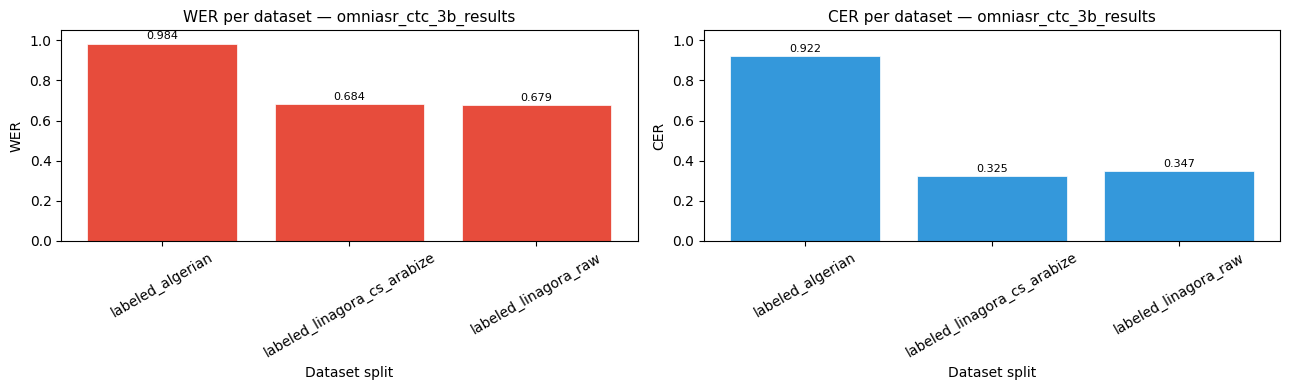

✓ Chart saved → /home/ala/TunisianDialogSystem/outputs/asr_benchmark_results/omniasr_ctc_3b_results/omniasr_ctc_3b_wer_cer_chart.png


In [ ]:
if summary_df is not None:
    plot_wer_cer(summary_df, OUTPUT_DIR, 'omniasr_ctc_300M', 'omniasr_ctc_300M_results')